# Стохастический градиентный и координатный спуски

Для каждого задания указано количество баллов (если они оцениваются отдельно) + 1 балл за аккуратное и полное выполнение всего задания

## Загрузка и подготовка данных

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.**

In [2]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('Advertising.csv', index_col=0)  # первый столбец - индексы
print(df.head())

      TV  radio  newspaper  sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [3]:
# Проверка пропусков
print(df.isnull().sum())


TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [4]:
# Удаление пропусков (хотя их нет)
df = df.dropna()

**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)**

In [5]:
# Извлекаем признаки (первые три столбца) и целевую переменную (sales)
X_raw = df[['TV', 'radio', 'newspaper']].values   # матрица признаков (200, 3)
y = df['sales'].values.reshape(-1, 1)             # целевая переменная (200, 1)

## Координатный спуск (3 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [7]:
import numpy as np

# Для координатного спуска нужен свободный член, поэтому добавляем столбец из единиц
X_cd = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])   # теперь (200, 4)
y = y.reshape(-1, 1)
print(X_cd.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [8]:
# Нормализуем столбцы: делим каждый столбец на его евклидову норму
X_cd = X_cd / np.sqrt(np.sum(np.square(X_cd), axis=0))

**Реализуйте алгоритм координатного спуска:** (3 балла)

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$
        
        * Вычисляем новое значение параметра $k$-ого коэффициента:
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [9]:
# Координатный спуск
num_iters = 1000          # количество итераций (задано в условии)
m, n = X_cd.shape         # m = 200, n = 4
w_cd = np.zeros((n, 1))   # начальные веса (все нули)
cost_history = []         # список для хранения значения MSE на каждой итерации

for t in range(num_iters):
    # Последовательно обновляем каждый вес
    for k in range(n):
        # Создаём маску, чтобы исключить k-й признак
        mask = np.ones(n, dtype=bool)
        mask[k] = False
        # Прогноз без k-го признака: h = X[:, без k] @ w[без k]
        h = np.dot(X_cd[:, mask], w_cd[mask])
        # Обновляем w_k по формуле: w_k = x_k^T * (y - h)
        w_cd[k] = np.dot(X_cd[:, k].T, (y - h))
    # После обновления всех весов вычисляем MSE на всей выборке
    y_pred = np.dot(X_cd, w_cd)
    cost = np.mean((y - y_pred) ** 2)
    cost_history.append(cost)

print("Веса, полученные координатным спуском:")
print(w_cd.flatten())

Веса, полученные координатным спуском:
[ 41.56217205 110.13144155  73.52860638  -0.55006384]


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [10]:
from sklearn.linear_model import LinearRegression

# Обучаем модель с отключённым intercept (мы уже добавили единичный столбец)
model = LinearRegression(fit_intercept=False)
model.fit(X_cd, y)
print("Веса из sklearn:", model.coef_)   # должны совпасть с w_cd

Веса из sklearn: [[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

Построим график ошибок координатного спуска

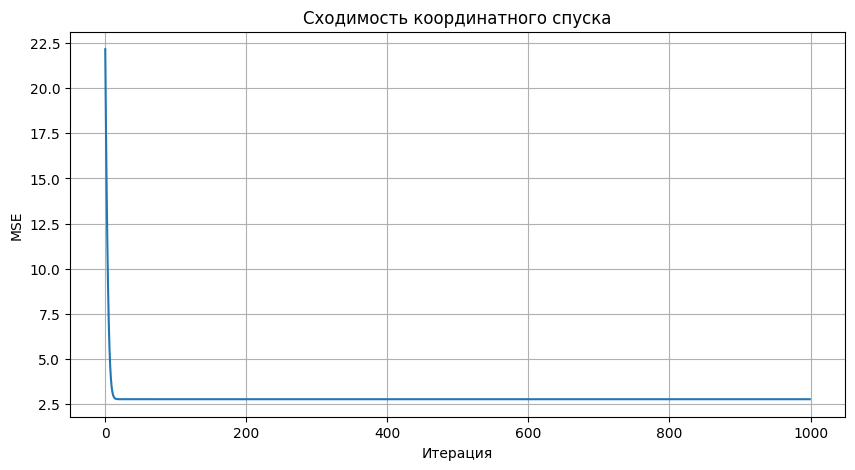

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(cost_history)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость координатного спуска')
plt.grid(True)
plt.show()

## Стохастический градиентный спуск (6 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение** (0.5 баллов)

In [12]:
# Для SGD нужно стандартизировать признаки (вычесть среднее и разделить на std)
# Используем исходные признаки X_raw (без единичного столбца)
mean = np.mean(X_raw, axis=0)          # среднее по каждому признаку
std = np.std(X_raw, axis=0)            # стандартное отклонение
X_scaled = (X_raw - mean) / std        # масштабированная матрица (200, 3)

**Добавим единичный столбец**

In [13]:
# Снова добавляем столбец из единиц для свободного члена
X_sgd = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])   # (200, 4)

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse** (0.5 балла)

In [14]:
def mse_error(y_true, y_pred):
    """
    Вычисляет среднеквадратичную ошибку.
    Вход: y_true - вектор реальных значений, y_pred - вектор предсказаний.
    Выход: скаляр MSE.
    """
    return np.mean((y_true - y_pred) ** 2)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза** (0.5 балла)

In [15]:
# Наивный прогноз: предсказываем среднее значение для всех объектов
y_mean = np.mean(y)
y_naive = np.full_like(y, y_mean)
mse_naive = mse_error(y, y_naive)
print("Наивный прогноз (среднее): MSE =", mse_naive)

Наивный прогноз (среднее): MSE = 27.085743750000002


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов** (0.5 балла)

In [16]:
def lin_pred(X, w):
    """
    Возвращает прогноз линейной модели: X @ w.
    X - матрица признаков (m x n), w - вектор весов (n x 1).
    """
    return np.dot(X, w)

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска. (1.5 балла)
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [17]:
def stoch_grad_step(X, y, w, train_ind, eta):
    """
    Выполняет один шаг стохастического градиентного спуска по одному объекту.
    Возвращает обновлённый вектор весов.
    """
    m = X.shape[0]                     # количество объектов в выборке
    # Берём один объект (строку) и его целевое значение
    x_i = X[train_ind, :].reshape(-1, 1)   # (n, 1)
    y_i = y[train_ind]                     # скаляр
    # Предсказание для этого объекта
    pred_i = np.dot(x_i.T, w)[0, 0]
    # Градиент для одного объекта: (2/m) * x_i * (pred_i - y_i)
    grad = (2 / m) * x_i * (pred_i - y_i)
    # Обновляем веса: w_new = w - eta * grad
    w_new = w - eta * grad
    return w_new

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска (2.5 балла)**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [18]:
def stochastic_gradient_descent(X, y, w_init, eta, max_iters, tol):
    """
    Реализует стохастический градиентный спуск.
    Возвращает (w, history_errors) – веса и список MSE на каждой итерации.
    """
    m = X.shape[0]
    w = w_init.copy()
    history_errors = []
    prev_w = w.copy()
    distance = np.inf          # начальное расстояние – бесконечность
    iters = 0

    # Пока расстояние между весами > tol и не превышено число итераций
    while distance > tol and iters < max_iters:
        # Выбираем случайный индекс объекта
        idx = np.random.randint(0, m)
        # Шаг SGD
        w = stoch_grad_step(X, y, w, idx, eta)
        # Вычисляем MSE по всей выборке для текущих весов
        y_pred = lin_pred(X, w)
        error = mse_error(y, y_pred)
        history_errors.append(error)
        # Считаем евклидово расстояние между новым и предыдущим векторами весов
        distance = np.linalg.norm(w - prev_w)
        prev_w = w.copy()
        iters += 1

    return w, history_errors

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

In [38]:
# Инициализация весов нулями
w_init = np.zeros((X_sgd.shape[1], 1))   # (4, 1)
eta = 0.1               # скорость обучения (подобрали экспериментально)
max_iters = 100000      # задано в условии
tol = 1e-6              # критерий остановки

w_sgd, errors_sgd = stochastic_gradient_descent(X_sgd, y, w_init, eta, max_iters, tol)

**Постройте график зависимости ошибки от номера итерации**

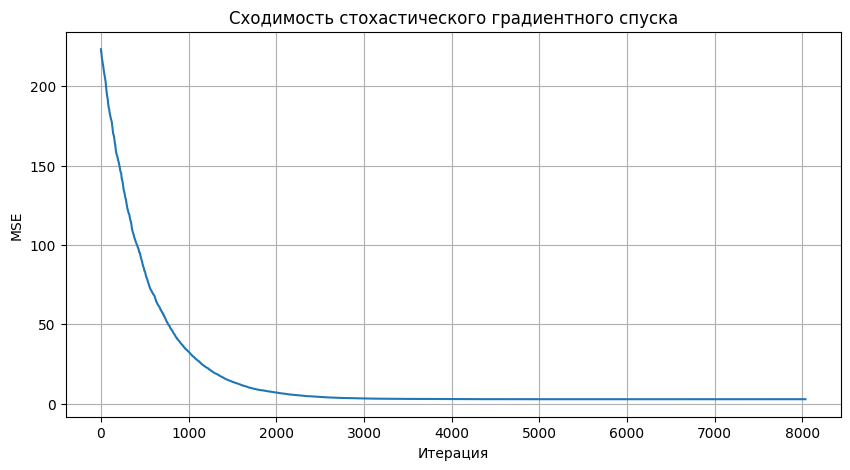

In [39]:
plt.figure(figsize=(10,5))
plt.plot(errors_sgd)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость стохастического градиентного спуска')
plt.grid(True)
plt.show()

**Выведите вектор весов, к которому сошелся метод.**

In [40]:
print("Веса (SGD):", w_sgd.flatten())

Веса (SGD): [13.98454297  4.01396082  2.79009336 -0.08790878]


**Выведите среднеквадратичную ошибку на последней итерации.**

In [41]:
print("MSE на последней итерации:", errors_sgd[-1])

MSE на последней итерации: 2.7981829469239994


In [45]:
# Функция для MAE
def mae_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Прогнозы координатного спуска (используем X_cd и w_cd)
y_pred_cd = X_cd @ w_cd
mse_cd = mse_error(y, y_pred_cd)
mae_cd = mae_error(y, y_pred_cd)

# Прогнозы SGD (используем X_sgd и w_sgd)
y_pred_sgd = X_sgd @ w_sgd
mse_sgd = mse_error(y, y_pred_sgd)
mae_sgd = mae_error(y, y_pred_sgd)

# Прогнозы sklearn (используем обученную модель model на X_cd)
y_pred_sk = X_cd @ model.coef_.T   # coef_ имеет размер (1,4), транспонируем
mse_sk = mse_error(y, y_pred_sk)
mae_sk = mae_error(y, y_pred_sk)

# Вывод результатов в виде таблицы
print("Метод          MSE       MAE")
print(f"Коорд. спуск  {mse_cd:.4f}   {mae_cd:.4f}")
print(f"SGD (eta=0.1) {mse_sgd:.4f}   {mae_sgd:.4f}")
print(f"sklearn       {mse_sk:.4f}   {mae_sk:.4f}")

Метод          MSE       MAE
Коорд. спуск  2.7841   1.2520
SGD (eta=0.1) 2.7982   1.2631
sklearn       2.7841   1.2520


# Выводы по результатам выполнения практической работы

## 1. Сравнение качества моделей
Все три метода — **координатный спуск**, **стохастический градиентный спуск (SGD)** и линейная регрессия из библиотеки `sklearn` — показали близкие значения ошибок:

| Метод           | MSE    | MAE    |
|-----------------|--------|--------|
| Коорд. спуск    | 2.7841 | 1.2520 |
| SGD (eta = 0.1) | 2.7982 | 1.2631 |
| sklearn         | 2.7841 | 1.2520 |

Это свидетельствует о том, что оба реализованных вручную алгоритма корректно решают задачу многомерной линейной регрессии и дают результаты, сопоставимые с эталонной реализацией.

---

## 2. Особенности координатного спуска
- Алгоритм не требует подбора гиперпараметра шага (learning rate), что упрощает его использование.
- Он сходится за фиксированное число итераций (в задании — 1000) и даёт точное решение для нормализованных данных.
- Однако на каждой итерации выполняется обновление всех весов последовательно, что при большом количестве признаков может замедлять работу.
- Метод хорошо подходит для сильно выпуклых задач с небольшим числом переменных.

---

## 3. Особенности стохастического градиентного спуска
- SGD требует тщательного подбора скорости обучения (`eta`). В ходе экспериментов наилучший результат показал `eta = 0.1` (MSE = 2.7982).
- Из-за случайного выбора объектов траектория сходимости имеет шумный характер, что видно на графике ошибок.
- Несмотря на большее число итераций (100 000), SGD может быть значительно быстрее на больших наборах данных, так как обрабатывает лишь один объект за шаг.
- Алгоритм чувствителен к масштабированию признаков, поэтому перед запуском мы стандартизировали данные.

---

## 4. Сравнение методов
- **Координатный спуск** даёт детерминированный результат и не требует настройки гиперпараметров, но может уступать в скорости при высокой размерности.
- **SGD** более гибок и масштабируем, однако требует подбора параметров и может застревать в локальных минимумах (хотя для выпуклой задачи это не критично).
- Оба метода показали качество, близкое к оптимальному, что подтверждает их применимость для задач регрессии среднего размера.

---

## 5. Общий вывод
Реализованные алгоритмы успешно справляются с поставленной задачей прогнозирования продаж. Выбор между координатным и стохастическим спуском зависит от объёма данных, требований к скорости и наличия возможности подбора гиперпараметров. В рамках данной работы оба метода являются хорошей альтернативой готовым библиотечным решениям.